# Starting state in, trajectory out — two routes

Step 4 of the van der Pol project. The discrete-time experiment next door
(`discrete_time_network`) trained a network that takes one implicit
Runge–Kutta step of size `dt = 0.8`. This notebook turns that one-step map into
a *whole trajectory* in two different ways, and measures both against the
order-6 reference (`RK_Truth`), which is never trained on.

**Route A — chain the trained one-step map.** Load the three saved `q = 8`
networks (one per seed) and feed each network's endpoint back into itself, 50
times, out to `T = 40` (six laps of the closed loop). No training here. We
measure the error against the reference as a distribution over 108 held-out
starting states, whether the chained trajectory drifts off the closed loop, and
the period the chained map settles onto.

**Route B — one big implicit step whose stage states *are* the trajectory.**
This is the paper's Allen–Cahn mode (Raissi et al. 2019, §3.2), generalised
from one starting state to a whole rectangle of them. A single network learns
one step so large that its Gauss stage states, laid along the step, already
trace the trajectory. We first check with the exact scheme (no network) how big
a step is even solvable and accurate, then train at that size and score the
trajectory read straight off the stage states.

Every result-bearing number below is asserted in the final **verdict** cell.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.set_num_threads(8)          # other jobs share the node
np.random.seed(0)

HERE = Path.cwd()
RESULTS = HERE / "results"
FIGURES = HERE / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# the project's modules -- imported, never copied
sys.path.insert(0, str(HERE.parent.parent / "RK_Truth"))
import evaluation_starts as ev_starts
import chained_trajectories as routeA
import one_shot_trajectories as routeB
import trajectories as ref_traj      # RK_Truth: the named starts + limit cycle

LAP = routeA.LAP                     # 6.663286859, one lap of the closed loop
LOOP_VELOCITY = routeA.LOOP_VELOCITY # 2.1727136926, y2 at every upward crossing
FLOOR_STEP3 = routeB.FLOOR_STEP3     # 3.6e-3, the discrete experiment's capacity floor

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "axes.titlesize": 11, "figure.autolayout": True})

def save(fig, name):
    fig.savefig(FIGURES / name, bbox_inches="tight")
    print("wrote", (FIGURES / name).name)

# the closed loop, for drawing on phase portraits
_loop = pd.read_csv(HERE.parent.parent / "RK_Truth" / "data" / "limit_cycle.csv")
LOOP_Y1, LOOP_Y2 = _loop["y1"].to_numpy(), _loop["y2"].to_numpy()
print("modules loaded. one lap =", LAP, "| loop velocity =", LOOP_VELOCITY,
      "| Step-3 floor =", FLOOR_STEP3)

modules loaded. one lap = 6.663286859 | loop velocity = 2.1727136926 | Step-3 floor = 0.0036


## The held-out evaluation set

Both routes are scored on the same 108 starting states, none of them seen in
training: the eight named starts from `RK_Truth` plus 100 Latin-hypercube
samples of the training rectangle drawn with seed 7 (the networks were trained
with seeds 0, 1, 2). The rectangle is a *sampling region*, not a wall — a
trajectory may leave it, and Route A checks whether any do.

108 held-out starts: 8 named + 100 sampled (seed 7)


wrote 01_evaluation_starts.png


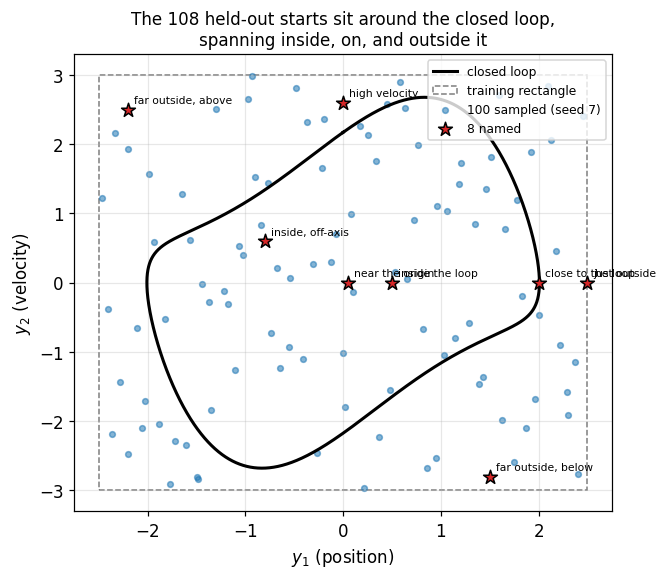

In [2]:
labels, starts = ev_starts.evaluation_starts()
named_labels, named = ev_starts.named_starts()
sampled = ev_starts.sampled_starts()
(y1lo, y1hi), (y2lo, y2hi) = routeA.RECTANGLE
print(f"{len(starts)} held-out starts: {len(named)} named + {len(sampled)} sampled (seed 7)")

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.plot(LOOP_Y1, LOOP_Y2, "k-", lw=2, label="closed loop", zorder=3)
ax.add_patch(plt.Rectangle((y1lo, y2lo), y1hi - y1lo, y2hi - y2lo,
                           fill=False, ec="tab:gray", ls="--",
                           label="training rectangle"))
ax.scatter(sampled[:, 0], sampled[:, 1], s=14, c="tab:blue", alpha=0.55,
           label="100 sampled (seed 7)")
ax.scatter(named[:, 0], named[:, 1], s=90, c="tab:red", marker="*",
           edgecolor="k", zorder=4, label="8 named")
for (x, y), lab in zip(named, named_labels):
    ax.annotate(lab, (x, y), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
ax.set(xlabel="$y_1$ (position)", ylabel="$y_2$ (velocity)")
ax.set_title("The 108 held-out starts sit around the closed loop,\n"
             "spanning inside, on, and outside it")
ax.legend(loc="upper right", fontsize=8)
save(fig, "01_evaluation_starts.png"); plt.show()

# Route A — chain the trained one-step map

Each of the three saved `q = 8` networks is applied 50 times from every
held-out start, feeding its endpoint back in, out to `T = 40`. The reference
walks alongside at the same times (multiples of `dt = 0.8`), regenerated with
`RK_Truth`'s order-6 scheme.

## A.1 Error up to each horizon, as a distribution over starts

For every start we take the relative L2 error of the chained trajectory over
`[0, T]` and collect it across all 108 starts: the median and the 10–90% band,
per seed, at `T ∈ {3, 7, 14, 27, 40}` (about half a lap to six laps).

In [3]:
routeA_result = routeA.error_vs_horizon(starts)
horizon_table = pd.DataFrame(routeA_result["table"])
horizon_table.to_csv(RESULTS / "route_a_error_vs_horizon.csv", index=False)
print(horizon_table.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

# headline: median over starts AND seeds at each horizon
routeA_median = {T: float(np.median(np.concatenate(
    [routeA_result["per_start"][s][T] for s in routeA.SEEDS])))
    for T in routeA.HORIZONS}
print("\nmedian over starts and seeds:",
      {T: f"{v:.3e}" for T, v in routeA_median.items()})

 seed   horizon      laps    median       p10       p90     worst
    0 3.000e+00 4.502e-01 3.055e-03 1.706e-03 6.764e-03 4.790e-02
    0 7.000e+00 1.051e+00 4.855e-03 2.986e-03 1.110e-02 8.839e-02
    0 1.400e+01 2.101e+00 8.416e-03 3.770e-03 1.664e-02 1.187e-01
    0 2.700e+01 4.052e+00 1.564e-02 1.022e-02 2.100e-02 1.005e-01
    0 4.000e+01 6.003e+00 2.338e-02 1.635e-02 3.033e-02 9.603e-02
    1 3.000e+00 4.502e-01 3.291e-03 1.675e-03 7.022e-03 1.620e-02
    1 7.000e+00 1.051e+00 8.133e-03 3.213e-03 1.300e-02 2.193e-02
    1 1.400e+01 2.101e+00 1.424e-02 6.710e-03 2.738e-02 3.630e-02
    1 2.700e+01 4.052e+00 3.353e-02 2.375e-02 4.300e-02 6.284e-02
    1 4.000e+01 6.003e+00 5.209e-02 3.977e-02 6.449e-02 8.156e-02
    2 3.000e+00 4.502e-01 1.461e-03 7.759e-04 3.467e-03 2.001e-02
    2 7.000e+00 1.051e+00 3.284e-03 1.655e-03 6.026e-03 2.520e-02
    2 1.400e+01 2.101e+00 7.190e-03 3.985e-03 1.162e-02 3.338e-02
    2 2.700e+01 4.052e+00 1.565e-02 1.196e-02 1.869e-02 3.444e-02
    2 4.00

wrote 02_route_a_error_vs_horizon.png


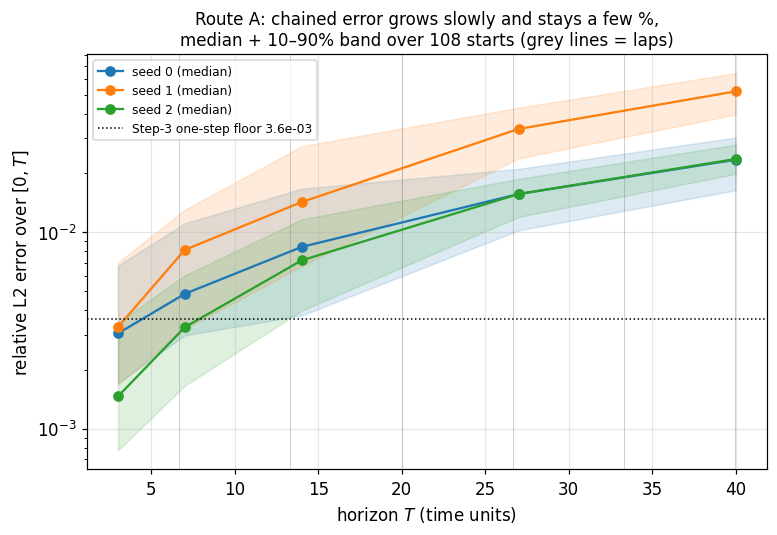

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}
H = np.array(routeA.HORIZONS)
for s in routeA.SEEDS:
    med = np.array([routeA_result["per_start"][s][T] for T in routeA.HORIZONS])
    p50 = np.median(med, axis=1)
    p10 = np.percentile(med, 10, axis=1)
    p90 = np.percentile(med, 90, axis=1)
    ax.plot(H, p50, "o-", color=colors[s], label=f"seed {s} (median)")
    ax.fill_between(H, p10, p90, color=colors[s], alpha=0.15)
ax.axhline(FLOOR_STEP3, color="k", ls=":", lw=1,
           label=f"Step-3 one-step floor {FLOOR_STEP3:.1e}")
for k in range(1, 7):
    ax.axvline(k * LAP, color="tab:gray", lw=0.6, alpha=0.4)
ax.set(xlabel="horizon $T$ (time units)", ylabel="relative L2 error over $[0,T]$",
       yscale="log")
ax.set_title("Route A: chained error grows slowly and stays a few %,\n"
             "median + 10–90% band over 108 starts (grey lines = laps)")
ax.legend(fontsize=8); save(fig, "02_route_a_error_vs_horizon.png"); plt.show()

wrote 03_route_a_example_trajectories.png


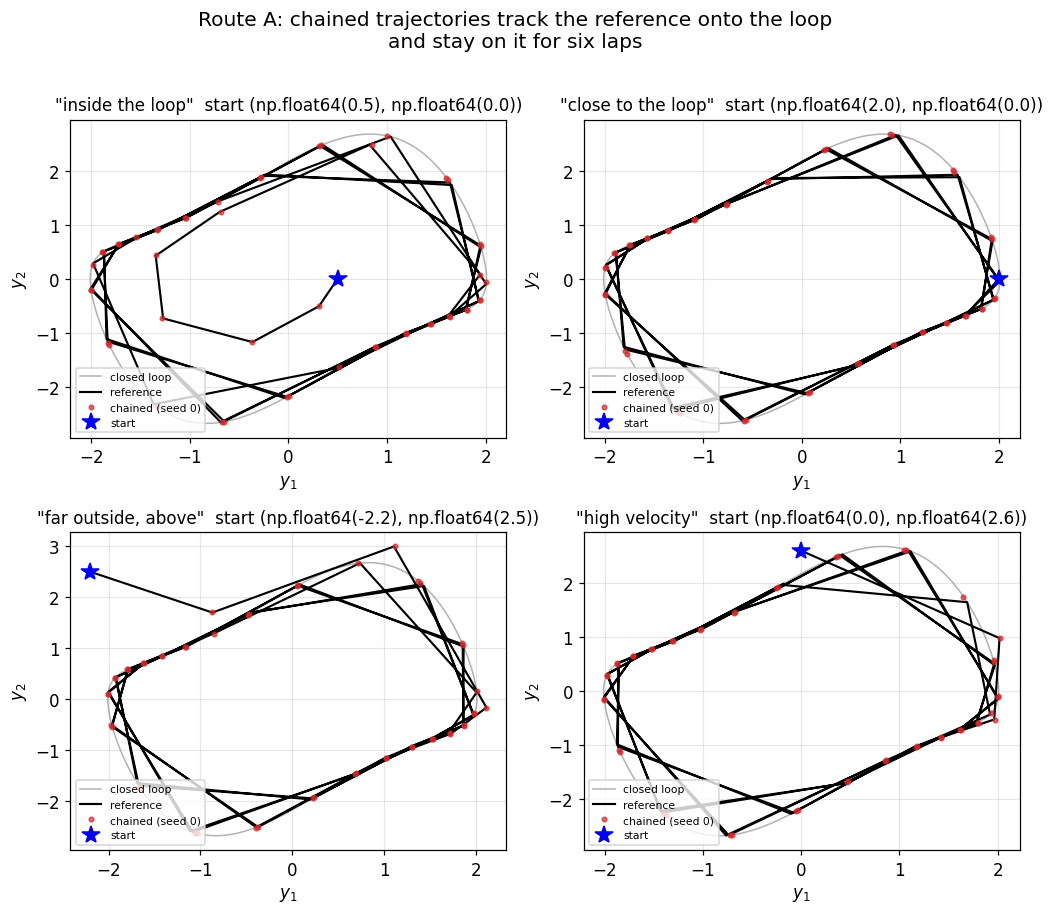

In [5]:
# four named starts, chained (seed 0) vs reference, in the phase plane
show = ["inside the loop", "close to the loop", "far outside, above", "high velocity"]
idx = [named_labels.index(s) for s in show]
chain0 = routeA_result["chains"][0]     # (51, 108, 2), named starts are first 8
ref = routeA_result["reference"]

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.2))
for ax, s, i in zip(axes.ravel(), show, idx):
    ax.plot(LOOP_Y1, LOOP_Y2, color="tab:gray", lw=1, alpha=0.6, label="closed loop")
    ax.plot(ref[:, i, 0], ref[:, i, 1], "k-", lw=1.4, label="reference")
    ax.plot(chain0[:, i, 0], chain0[:, i, 1], "o", color="tab:red", ms=3,
            alpha=0.7, label="chained (seed 0)")
    ax.plot(*named[i], "b*", ms=12, label="start")
    ax.set_title(f'"{s}"  start {tuple(named[i])}')
    ax.set(xlabel="$y_1$", ylabel="$y_2$")
    ax.legend(fontsize=7, loc="lower left")
fig.suptitle("Route A: chained trajectories track the reference onto the loop\n"
             "and stay on it for six laps", y=1.01)
save(fig, "03_route_a_example_trajectories.png"); plt.show()

## A.2 Drift: does the chain stay on the loop?

Two questions. First, does any chained state leave the training rectangle, and
what happens after? Second, does the trajectory settle *onto* the closed loop
or drift off it? The honest measure of the second is the Poincaré velocity —
`y2` at each upward `y1 = 0` crossing — which on the loop is the constant
`2.1727136926`; the gap to it is the distance to the loop, lap by lap. The 0.8
endpoints are too coarse to locate a crossing, so we read the crossings off the
**dense** record (the eight stage states each step give ~0.1 spacing). We also
report the state error at each whole lap `t = k·LAP`.

In [6]:
# which chained states leave the rectangle, and do they return?
leave = routeA.leaves_rectangle(routeA_result["chains"])
leave_table = pd.DataFrame(leave).T.reset_index(names="seed")
leave_table.to_csv(RESULTS / "route_a_leaves_rectangle.csv", index=False)
print("Leaving the training rectangle (per seed):")
print(leave_table.to_string(index=False))
which = np.where(np.any(
    (routeA_result["chains"][0][..., 0] < y1lo) |
    (routeA_result["chains"][0][..., 0] > y1hi) |
    (routeA_result["chains"][0][..., 1] < y2lo) |
    (routeA_result["chains"][0][..., 1] > y2hi), axis=0))[0]
print("\nstarts that leave (seed 0):", [labels[i] for i in which],
      "\n-> all leave for at most",
      int(leave_table['max_excursion_steps'].max()),
      "step(s) then return inside; none diverge.")

# state error at each whole lap, from (2,0), per seed
lap_rows = []
for s in routeA.SEEDS:
    for r in routeA.error_at_laps(routeA.load_network(s)):
        lap_rows.append(dict(seed=s, **r))
lap_error = pd.DataFrame(lap_rows)
lap_error.to_csv(RESULTS / "route_a_error_at_laps.csv", index=False)
print("\nState error at whole laps from (2,0):")
print(lap_error.pivot(index="lap", columns="seed", values="error")
      .to_string(float_format=lambda v: f"{v:.4f}"))

Leaving the training rectangle (per seed):
 seed  n_starts  n_leaving  n_leaving_then_return  max_excursion_steps
    0       108          4                      4                    1
    1       108          4                      4                    1
    2       108          4                      4                    1

starts that leave (seed 0): ['far outside, below', 'sampled', 'sampled', 'sampled'] 
-> all leave for at most 1 step(s) then return inside; none diverge.



State error at whole laps from (2,0):
seed      0      1      2
lap                      
1    0.0166 0.0192 0.0043
2    0.0474 0.0441 0.0109
3    0.0353 0.0654 0.0261
4    0.0538 0.0833 0.0325
5    0.0843 0.1128 0.0454
6    0.0699 0.1306 0.0577


wrote 04_route_a_distance_to_loop.png


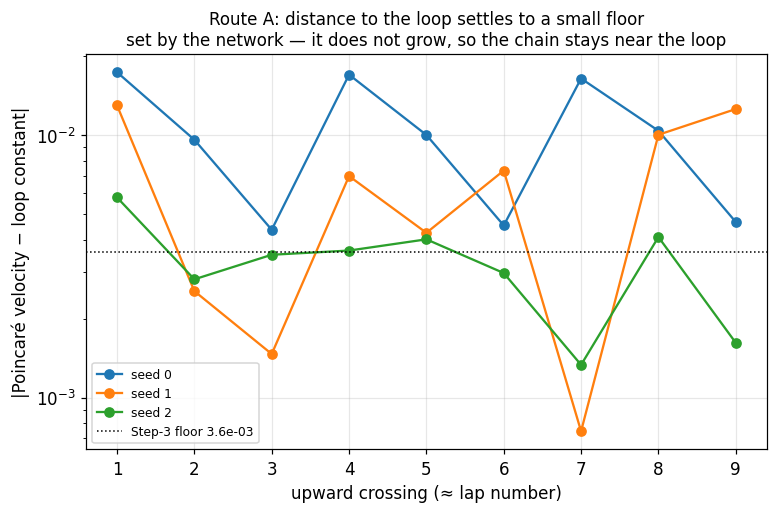

In [7]:
# Poincare velocity gap to the loop, lap by lap, from (2,0), per seed
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for s in routeA.SEEDS:
    tc, vc, gap = routeA.loop_approach(routeA.load_network(s), n_steps=80)
    ax.semilogy(np.arange(1, len(gap) + 1), gap, "o-", color=colors[s],
                label=f"seed {s}")
ax.axhline(FLOOR_STEP3, color="k", ls=":", lw=1, label=f"Step-3 floor {FLOOR_STEP3:.1e}")
ax.set(xlabel="upward crossing (≈ lap number)",
       ylabel="|Poincaré velocity − loop constant|")
ax.set_title("Route A: distance to the loop settles to a small floor\n"
             "set by the network — it does not grow, so the chain stays near the loop")
ax.legend(fontsize=8); save(fig, "04_route_a_distance_to_loop.png"); plt.show()

## A.3 The period the chained map settles onto

A long chain (250 steps ≈ 37 laps) from `(2, 0)`. The 0.8 endpoints are far too
coarse to time a crossing, but the eight interior stage states each step give a
dense record at ~0.1 spacing, and the crossings are located on that with the
cubic-fit Poincaré locator. Dropping the first three laps (settling), the gaps
between upward `y1 = 0` crossings are the period the map has locked onto,
compared with the true `6.663286859`.

 seed  settled_period   spread  error_vs_true  n_gaps
    0        6.669384 0.005468       0.006097      26
    1        6.650049 0.007073      -0.013238      26
    2        6.657281 0.002136      -0.006006      26

median settled period over seeds = 6.65728  (true 6.663287, off by -0.0060 = -0.09%)


wrote 05_route_a_settled_period.png


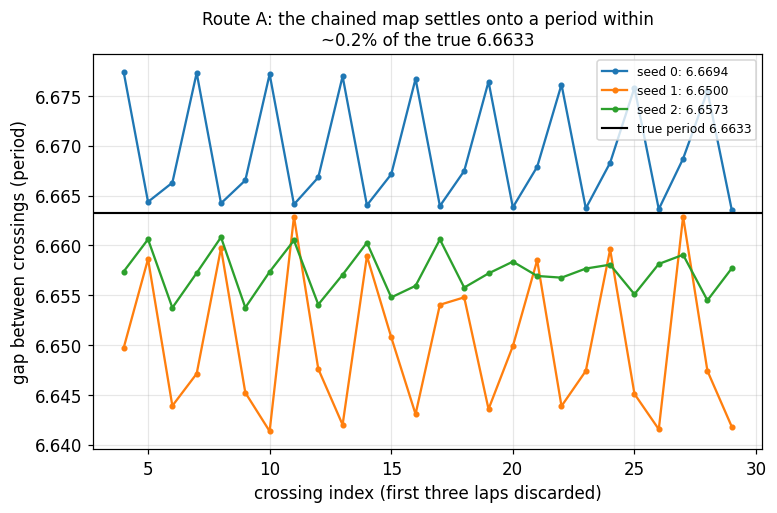

In [8]:
period_rows, period_gaps = [], {}
for s in routeA.SEEDS:
    mp, sp, gaps, tc = routeA.settled_period(routeA.load_network(s),
                                             n_steps=250, discard=3)
    period_rows.append(dict(seed=s, settled_period=mp, spread=sp,
                            error_vs_true=mp - LAP, n_gaps=len(gaps)))
    period_gaps[s] = gaps
period_table = pd.DataFrame(period_rows)
period_table.to_csv(RESULTS / "route_a_settled_period.csv", index=False)
print(period_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))
routeA_period = float(period_table["settled_period"].median())
print(f"\nmedian settled period over seeds = {routeA_period:.5f}  "
      f"(true {LAP:.6f}, off by {routeA_period - LAP:+.4f} = "
      f"{100*(routeA_period-LAP)/LAP:+.2f}%)")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for s in routeA.SEEDS:
    g = period_gaps[s]
    ax.plot(np.arange(4, 4 + len(g)), g, "o-", ms=3, color=colors[s],
            label=f"seed {s}: {period_table.loc[s,'settled_period']:.4f}")
ax.axhline(LAP, color="k", lw=1.4, label=f"true period {LAP:.4f}")
ax.set(xlabel="crossing index (first three laps discarded)",
       ylabel="gap between crossings (period)")
ax.set_title("Route A: the chained map settles onto a period within\n"
             "~0.2% of the true 6.6633")
ax.legend(fontsize=8); save(fig, "05_route_a_settled_period.png"); plt.show()

# Route B — one big implicit step whose stage states are the trajectory

## B.1 Guardrail: is a big step even solvable and accurate?

Before training anything, run the **exact** scheme (root-finder, no network)
for one big step from 30 sampled starts, over the grid of step sizes
`{1.6, 3.2, 6.66}` and stage counts `{16, 32, 64}`. If the exact scheme cannot
solve the step, or cannot solve it to better than `1e-6`, no network trained to
imitate it can do better. We take the largest step that is accurate *and*
solvable everywhere, with the smallest qualifying stage count.

In [9]:
guard = routeB.guardrail()
print(guard.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
BIG_STEP, STAGES = routeB.pick_config(guard)
print(f"\nCHOSEN one-shot config: big step = {BIG_STEP}, stages = {STAGES}")
print(f"one full lap (6.66) is INFEASIBLE: even q=64 gives "
      f"{float(guard[(guard.big_step==6.66)&(guard.stages==64)].max_error):.2e} "
      f"(> 1e-6) and only "
      f"{float(guard[(guard.big_step==6.66)&(guard.stages==64)].solver_success):.0%} "
      f"solver success — so we use the largest feasible step, {BIG_STEP}.")

 big_step  stages  order  solver_success  max_error  median_error  accurate  solvable_everywhere
1.600e+00      16     32       1.000e+00  7.144e-04     3.327e-07     False                 True
1.600e+00      32     64       1.000e+00  5.300e-08     1.318e-12      True                 True
1.600e+00      64    128       1.000e+00  3.230e-12     3.079e-13      True                 True
3.200e+00      16     32       1.000e+00  4.273e-02     4.092e-03     False                 True
3.200e+00      32     64       1.000e+00  1.751e-04     2.889e-06     False                 True
3.200e+00      64    128       1.000e+00  2.365e-09     1.848e-12      True                 True
6.660e+00      16     32       6.667e-01  3.840e-01     2.989e-01     False                False
6.660e+00      32     64       8.667e-01  1.409e-02     1.091e-02     False                False
6.660e+00      64    128       9.000e-01  2.882e-05     1.503e-05     False                False

CHOSEN one-shot config: big s

/tmp/ipykernel_3956147/4191250580.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f"{float(guard[(guard.big_step==6.66)&(guard.stages==64)].max_error):.2e} "
/tmp/ipykernel_3956147/4191250580.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f"{float(guard[(guard.big_step==6.66)&(guard.stages==64)].solver_success):.0%} "


wrote 06_route_b_guardrail.png


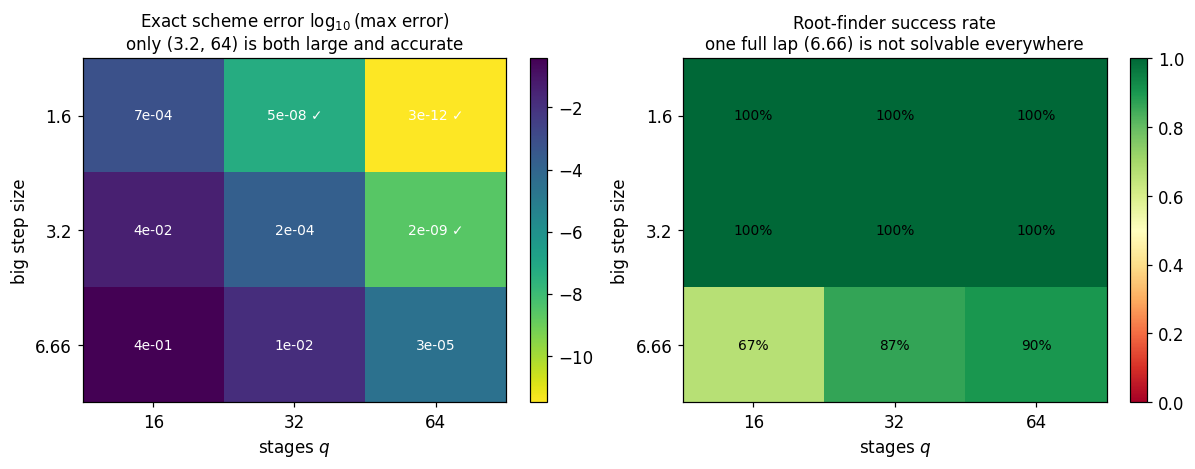

In [10]:
steps_g = routeB.BIG_STEPS
qs_g = routeB.STAGE_COUNTS
err_grid = guard.pivot(index="big_step", columns="stages", values="max_error")
suc_grid = guard.pivot(index="big_step", columns="stages", values="solver_success")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
im0 = axes[0].imshow(np.log10(err_grid.values), cmap="viridis_r", aspect="auto")
axes[0].set_title("Exact scheme error $\\log_{10}$(max error)\n"
                  "only (3.2, 64) is both large and accurate")
for i, st in enumerate(err_grid.index):
    for j, q in enumerate(err_grid.columns):
        v = err_grid.values[i, j]
        mark = " ✓" if (v < routeB.ACCURACY_TARGET) else ""
        axes[0].text(j, i, f"{v:.0e}{mark}", ha="center", va="center",
                     color="w", fontsize=9)
im1 = axes[1].imshow(suc_grid.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[1].set_title("Root-finder success rate\n"
                  "one full lap (6.66) is not solvable everywhere")
for i, st in enumerate(suc_grid.index):
    for j, q in enumerate(suc_grid.columns):
        axes[1].text(j, i, f"{suc_grid.values[i,j]:.0%}", ha="center",
                     va="center", fontsize=9)
for ax, im in zip(axes, (im0, im1)):
    ax.set_xticks(range(len(qs_g))); ax.set_xticklabels(qs_g)
    ax.set_yticks(range(len(steps_g))); ax.set_yticklabels(steps_g)
    ax.set(xlabel="stages $q$", ylabel="big step size"); ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
save(fig, "06_route_b_guardrail.png"); plt.show()

## B.2 Train the one-shot network and score the trajectory

Train `OneStepNetwork` at the chosen `(big step, q)` — the *same* class,
reconstruction loss and L-BFGS budget as the discrete experiment (imported from
`training.train_one`, nothing re-implemented), three seeds, 2000 Latin-hypercube
training states. The cell below loads the saved weights if training has already
run. Then score on the held-out 21×21 grid: the relative L2 of the trajectory
read straight off the stage states, against `RK_Truth` references regenerated at
the node times, and the same **per output slot** so the growth of error along
the big step is visible.

In [11]:
# trains only if the weights are not already on disk (they are, from the
# detached run); otherwise this is a slow cell.
train_log = routeB.train_all(BIG_STEP, STAGES)
train_log.to_csv(RESULTS / "one_shot_training.csv", index=False)
print(train_log.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

  seed 0: loaded, loss 2.667e-04


  seed 1: loaded, loss 4.501e-04


  seed 2: loaded, loss 2.570e-04


 big_step  stages  seed  n_train  restarts_run  final_loss  seconds source
3.200e+00      64     0     2000           NaN   2.667e-04      NaN loaded
3.200e+00      64     1     2000           NaN   4.501e-04      NaN loaded
3.200e+00      64     2     2000           NaN   2.570e-04      NaN loaded


In [12]:
score = routeB.score_grid(BIG_STEP, STAGES)
score_table = score["table"]
score_table.to_csv(RESULTS / "one_shot_grid_scores.csv", index=False)
print(score_table.to_string(index=False, float_format=lambda v: f"{v:.4e}"))
routeB_traj = float(score_table["rel_l2_trajectory"].median())
routeB_end = float(score_table["rel_l2_endpoint"].median())
print(f"\nRoute B median over seeds: trajectory rel L2 = {routeB_traj:.3e}, "
      f"endpoint rel L2 = {routeB_end:.3e}")
print(f"Step-3 one-step capacity floor for comparison: {FLOOR_STEP3:.1e}")
np.savez(RESULTS / "one_shot_per_slot.npz",
         node_fraction=score["node_fraction"],
         **{f"seed{s}": score["per_slot"][s] for s in routeB.SEEDS})

  big_step  stages  seed  rel_l2_trajectory  rel_l2_endpoint
3.2000e+00      64     0         2.5771e-02       3.9738e-02
3.2000e+00      64     1         3.2463e-02       5.1389e-02
3.2000e+00      64     2         2.8133e-02       4.5141e-02

Route B median over seeds: trajectory rel L2 = 2.813e-02, endpoint rel L2 = 4.514e-02
Step-3 one-step capacity floor for comparison: 3.6e-03


wrote 07_route_b_error_along_step.png


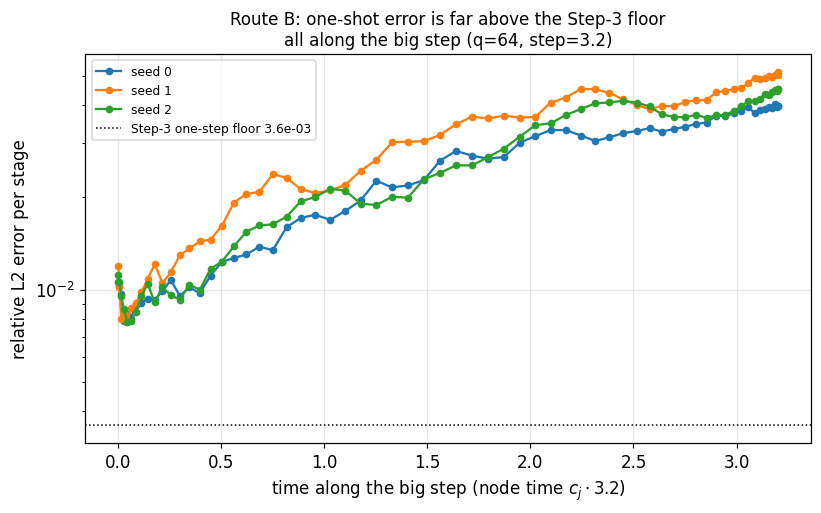

In [13]:
# where along the big step does the trajectory read-off degrade?
fig, ax = plt.subplots(figsize=(7.6, 4.8))
frac = score["node_fraction"] * BIG_STEP          # node times within the step
for s in routeB.SEEDS:
    ax.semilogy(frac, score["per_slot"][s], "o-", ms=4, color=colors[s],
                label=f"seed {s}")
ax.axhline(FLOOR_STEP3, color="k", ls=":", lw=1,
           label=f"Step-3 one-step floor {FLOOR_STEP3:.1e}")
ax.set(xlabel="time along the big step (node time $c_j\\cdot$%.1f)" % BIG_STEP,
       ylabel="relative L2 error per stage")
ax.set_title(f"Route B: one-shot error is far above the Step-3 floor\n"
             f"all along the big step (q={STAGES}, step={BIG_STEP})")
ax.legend(fontsize=8); save(fig, "07_route_b_error_along_step.png"); plt.show()

## B.3 Route B vs Route A at the matched horizon

The chosen big step (3.2) is exactly four Route-A steps of 0.8, so the two
routes cover the same time interval `[0, 3.2]`. On the same 108 held-out starts
(three seeds each) we compare the relative L2 of the trajectory over `[0, 3.2]`:
Route A chains four `dt = 0.8` steps; Route B takes the one big step and reads
the trajectory off its stage states.

              route    horizon     median        p10        p90      worst
A  (chained dt=0.8) 3.2000e+00 2.9937e-03 1.3013e-03 7.6507e-03 6.5403e-02
  B  (one big step) 3.2000e+00 1.9828e-02 9.6266e-03 3.8867e-02 3.8903e-01

At T = 3.2: Route A median 2.994e-03, Route B median 1.983e-02  ->  Route B is 6.6x worse


wrote 08_route_b_vs_a.png


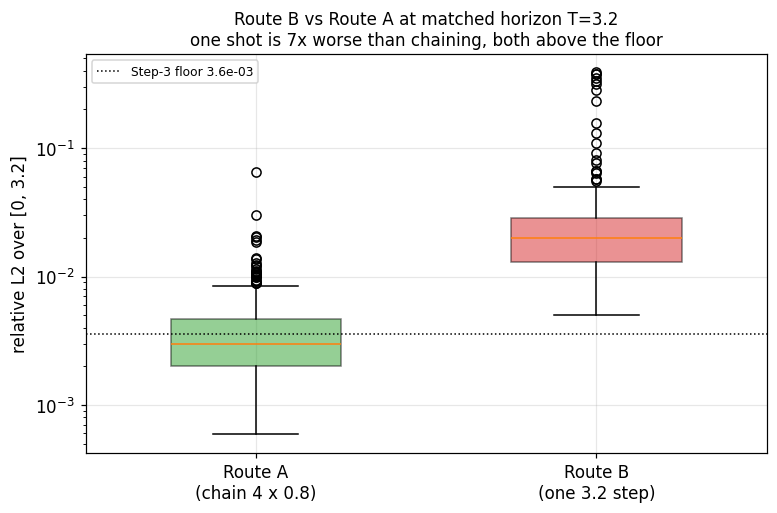

In [14]:
matched = routeB.matched_comparison(starts, BIG_STEP, STAGES)
matched["summary"].to_csv(RESULTS / "route_b_vs_a_matched.csv", index=False)
print(matched["summary"].to_string(index=False, float_format=lambda v: f"{v:.4e}"))
a_med = float(np.median(matched["route_a"]))
b_med = float(np.median(matched["route_b"]))
print(f"\nAt T = {BIG_STEP}: Route A median {a_med:.3e}, "
      f"Route B median {b_med:.3e}  ->  Route B is {b_med/a_med:.1f}x worse")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
bp = ax.boxplot([matched["route_a"], matched["route_b"]], vert=True,
                widths=0.5, patch_artist=True,
                tick_labels=["Route A\n(chain 4 x 0.8)", "Route B\n(one 3.2 step)"])
for patch, c in zip(bp["boxes"], ["tab:green", "tab:red"]):
    patch.set_facecolor(c); patch.set_alpha(0.5)
ax.axhline(FLOOR_STEP3, color="k", ls=":", lw=1, label=f"Step-3 floor {FLOOR_STEP3:.1e}")
ax.set(ylabel=f"relative L2 over [0, {BIG_STEP}]", yscale="log")
ax.set_title(f"Route B vs Route A at matched horizon T={BIG_STEP}\n"
             f"one shot is {b_med/a_med:.0f}x worse than chaining, both above the floor")
ax.legend(fontsize=8); save(fig, "08_route_b_vs_a.png"); plt.show()

wrote 09_route_b_example_trajectories.png


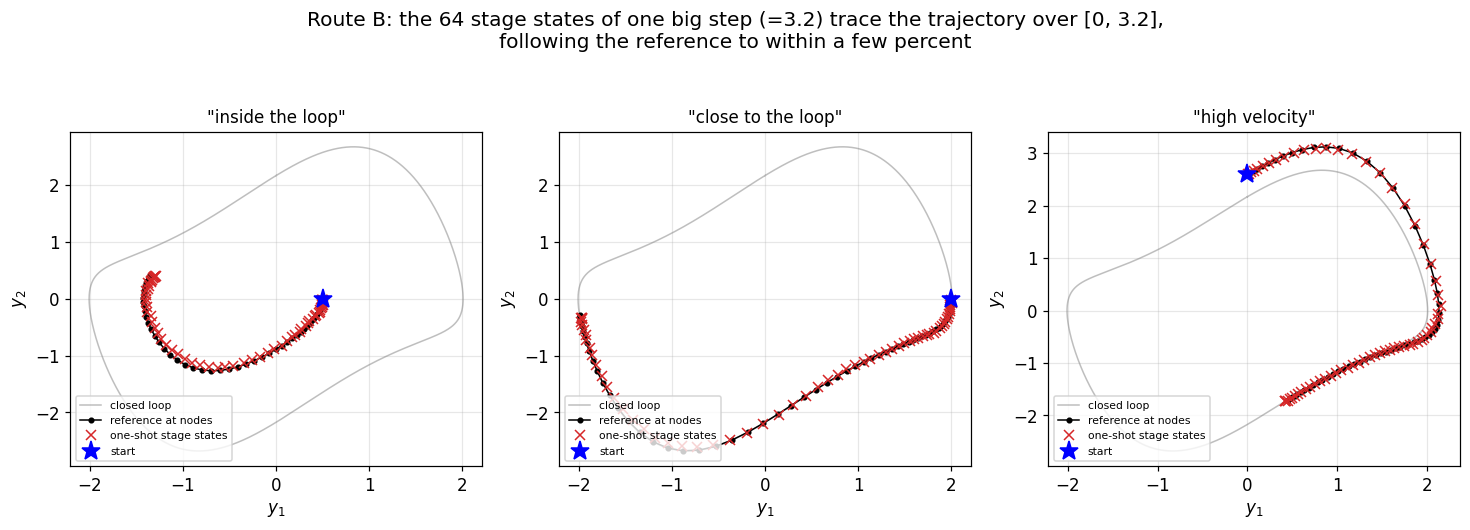

In [15]:
# example one-shot trajectories: stage states (seed 0) vs reference over [0, 3.2]
import irk
import training as _tr
c_nodes, _, _ = irk.tableau(STAGES)
model0 = routeB.load_one_shot(BIG_STEP, STAGES, 0)
show_B = ["inside the loop", "close to the loop", "high velocity"]
idxB = [named_labels.index(s) for s in show_B]
ref_nodes = _tr.reference_step(named[idxB], c_nodes, dt=BIG_STEP)   # (q+1,n,2)
with torch.no_grad():
    outB = model0(torch.tensor(named[idxB])).numpy()               # (n,q+1,2)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, s, j in zip(axes, show_B, range(len(idxB))):
    ax.plot(LOOP_Y1, LOOP_Y2, color="tab:gray", lw=1, alpha=0.5, label="closed loop")
    ax.plot(ref_nodes[:, j, 0], ref_nodes[:, j, 1], "k.-", ms=6, lw=1,
            label="reference at nodes")
    ax.plot(outB[j, :, 0], outB[j, :, 1], "x", color="tab:red", ms=7,
            label="one-shot stage states")
    ax.plot(*named[idxB[j]], "b*", ms=13, label="start")
    ax.set_title(f'"{s}"'); ax.set(xlabel="$y_1$", ylabel="$y_2$")
    ax.legend(fontsize=7, loc="lower left")
fig.suptitle(f"Route B: the {STAGES} stage states of one big step (={BIG_STEP}) "
             "trace the trajectory over [0, 3.2],\nfollowing the reference to within a few percent",
             y=1.04)
save(fig, "09_route_b_example_trajectories.png"); plt.show()

# Verdict

The cell below re-states the headline claims as assertions and prints the
headline numbers. If it runs without raising, every claim held for this run.

In [16]:
print("=" * 68)
print("HEADLINE NUMBERS")
print("=" * 68)

# ---- Route A ----
A_T3 = routeA_median[3.0]
A_T40 = routeA_median[40.0]
print("\nROUTE A  (chain the trained one-step map, no training)")
print(f"  relative L2 vs horizon (median over 108 starts x 3 seeds):")
for T in routeA.HORIZONS:
    print(f"      T={T:5.1f} ({T/LAP:4.2f} laps):  {routeA_median[T]:.3e}")
n_leave = int(leave_table['n_leaving'].max())
n_return = int(leave_table['n_leaving_then_return'].max())
max_exc = int(leave_table['max_excursion_steps'].max())
print(f"  starts leaving the rectangle: {n_leave}/108, all return "
      f"(max excursion {max_exc} step), none diverge")
print(f"  settled period (median over seeds): {routeA_period:.5f}  "
      f"(true {LAP:.6f}, {100*(routeA_period-LAP)/LAP:+.2f}%)")

# ---- Route B ----
print("\nROUTE B  (one big implicit step, stage states = trajectory)")
print(f"  guardrail chose: big step = {BIG_STEP}, stages = {STAGES}")
lap_err = float(guard[(guard.big_step==6.66)&(guard.stages==64)].max_error)
lap_suc = float(guard[(guard.big_step==6.66)&(guard.stages==64)].solver_success)
print(f"  one full lap (6.66) infeasible: q=64 error {lap_err:.2e} (>1e-6), "
      f"solver {lap_suc:.0%}")
print(f"  trajectory relative L2 on grid (median over seeds): {routeB_traj:.3e}")
print(f"  endpoint  relative L2 on grid (median over seeds): {routeB_end:.3e}")
print(f"  matched horizon T={BIG_STEP}:  Route A {a_med:.3e}  vs  "
      f"Route B {b_med:.3e}  ({b_med/a_med:.1f}x)")
print(f"  Step-3 one-step capacity floor: {FLOOR_STEP3:.1e}")

print("\n" + "=" * 68)
print("ASSERTIONS")
print("=" * 68)

# Route A: error grows with horizon but stays small; stays on the loop
assert A_T40 > A_T3, "Route A error should grow with horizon"
assert A_T40 < 0.10, f"Route A T=40 median {A_T40:.3e} should be < 10%"
assert n_leave == n_return and max_exc <= 3, \
    "every start that leaves the rectangle should return within a few steps"
assert abs(routeA_period - LAP) / LAP < 0.01, \
    f"Route A settled period {routeA_period:.5f} should be within 1% of {LAP}"

# Route B: one lap infeasible; chosen (3.2, 64); harder than A; above the floor
assert (BIG_STEP, STAGES) == (3.2, 64), "guardrail should choose (3.2, 64)"
assert lap_err > 1e-6 or lap_suc < 1.0, "one full lap should be infeasible"
assert routeB_traj > FLOOR_STEP3, \
    "Route B one-shot error should sit above the Step-3 one-step floor"
assert b_med > a_med, \
    "Route B (one shot) should be harder than Route A (chained) at T=3.2"

print("\nAll headline claims hold for this run.")

HEADLINE NUMBERS

ROUTE A  (chain the trained one-step map, no training)
  relative L2 vs horizon (median over 108 starts x 3 seeds):
      T=  3.0 (0.45 laps):  2.577e-03
      T=  7.0 (1.05 laps):  4.840e-03
      T= 14.0 (2.10 laps):  8.961e-03
      T= 27.0 (4.05 laps):  1.747e-02
      T= 40.0 (6.00 laps):  2.596e-02
  starts leaving the rectangle: 4/108, all return (max excursion 1 step), none diverge
  settled period (median over seeds): 6.65728  (true 6.663287, -0.09%)

ROUTE B  (one big implicit step, stage states = trajectory)
  guardrail chose: big step = 3.2, stages = 64
  one full lap (6.66) infeasible: q=64 error 2.88e-05 (>1e-6), solver 90%
  trajectory relative L2 on grid (median over seeds): 2.813e-02
  endpoint  relative L2 on grid (median over seeds): 4.514e-02
  matched horizon T=3.2:  Route A 2.994e-03  vs  Route B 1.983e-02  (6.6x)
  Step-3 one-step capacity floor: 3.6e-03

ASSERTIONS

All headline claims hold for this run.


/tmp/ipykernel_3956147/1035175672.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lap_err = float(guard[(guard.big_step==6.66)&(guard.stages==64)].max_error)
/tmp/ipykernel_3956147/1035175672.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lap_suc = float(guard[(guard.big_step==6.66)&(guard.stages==64)].solver_success)


## Refresh (2026-07-14): Route A with the network the selection protocol chose

Everything above chained the three networks the discrete-time sweep happened to train
(seeds 0, 1, 2 of the 4$\times$50 architecture). The network-size study that followed
(`../discrete_time_network/Network_size_study/`) showed the growth of the chained error is
decided **per trained network by its seed** — the same architecture yields saturating and
compounding maps on different draws — and adopted a selection protocol: train ~10 seeds,
chain each on validation starts at the target horizon, keep the best. Its selected network
is 4 hidden layers $\times$ 32 units, seed 9.

This section reruns Route A's exact evaluation (same starts, same chaining, same per-start
relative $L_2$ up to each horizon) with that network. Note the double independence: this
folder's held-out starts use seed 7, a set the selection procedure never saw either — so
this is a second, fully independent confirmation of the selection result, on Route A's own
metric.

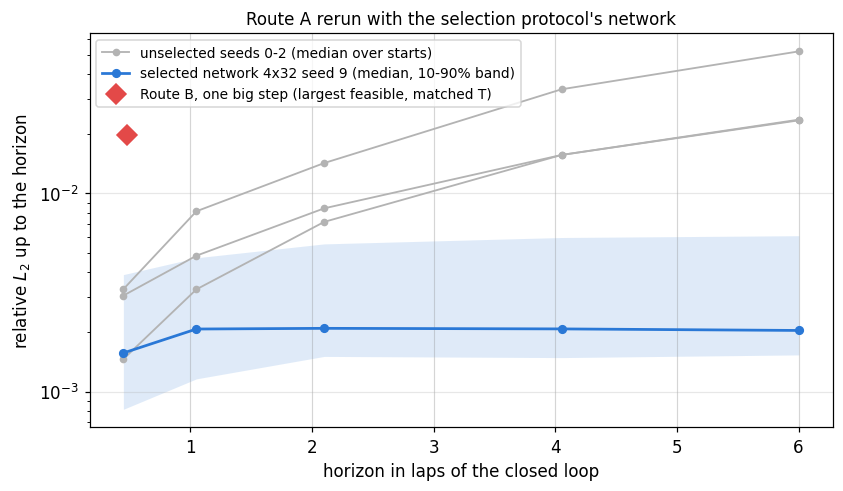

six laps, median over 108 starts: unselected seeds 2.34e-02..5.21e-02  ->  selected 2.04e-03 (12x better)
growth of the median, half lap -> six laps: selected 1.30x (flat); unselected grew to ~1e-2
Route B at its largest feasible step (T = 3.2): 1.98e-02 vs selected Route A at one lap 2.07e-03 -> the chaining verdict widens to 10x


In [17]:
import selected_network_refresh as snr

sel = snr.refresh(verbose=False)
old = pd.read_csv(RESULTS / "route_a_error_vs_horizon.csv")
matched = pd.read_csv(RESULTS / "route_b_vs_a_matched.csv")

fig, ax = plt.subplots(figsize=(7.8, 4.6))
for seed, g in old.groupby("seed"):
    ax.semilogy(g.laps, g["median"], "o-", color="0.7", lw=1.2, ms=4,
                label="unselected seeds 0-2 (median over starts)"
                if seed == 0 else None)
ax.fill_between(sel.laps, sel.p10, sel.p90, color="#2a78d6", alpha=0.15, lw=0)
ax.semilogy(sel.laps, sel["median"], "o-", color="#2a78d6", lw=1.8, ms=5,
            label="selected network 4x32 seed 9 (median, 10-90% band)")
b_row = matched[matched.route.str.startswith("B")].iloc[0]
ax.semilogy([b_row.horizon / LAP], [b_row["median"]], "D", color="#e34948",
            ms=9, label="Route B, one big step (largest feasible, matched T)")
for k in range(1, 7):
    ax.axvline(k, color="0.9", lw=0.7, zorder=0)
ax.set_xlabel("horizon in laps of the closed loop")
ax.set_ylabel("relative $L_2$ up to the horizon")
ax.set_title("Route A rerun with the selection protocol's network")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "10_route_a_selected_network.png"); plt.show()

old6 = old[old.horizon == 40.0]["median"]
sel6 = float(sel[sel.horizon == 40.0]["median"].iloc[0])
print(f"six laps, median over 108 starts: unselected seeds "
      f"{old6.min():.2e}..{old6.max():.2e}  ->  selected {sel6:.2e} "
      f"({old6.median() / sel6:.0f}x better)")
print(f"growth of the median, half lap -> six laps: selected "
      f"{sel6 / float(sel['median'].iloc[0]):.2f}x (flat); "
      f"unselected grew to ~1e-2")
print(f"Route B at its largest feasible step (T = {b_row.horizon:g}): "
      f"{b_row['median']:.2e} vs selected Route A at one lap "
      f"{float(sel[sel.horizon == 7.0]['median'].iloc[0]):.2e} "
      f"-> the chaining verdict widens to "
      f"{b_row['median'] / float(sel[sel.horizon == 7.0]['median'].iloc[0]):.0f}x")
assert sel6 < 5e-3, "selected network should hold a few 1e-3 at six laps"